<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> AI For Leaders - 2 <br>
<b>Semester:</b> Spring 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [36]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))


Text(0, 0.5, 'Loss function')

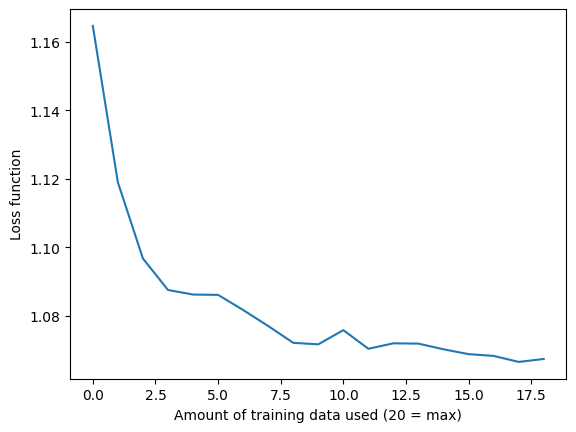

In [38]:
import matplotlib.pyplot as plt

plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [39]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

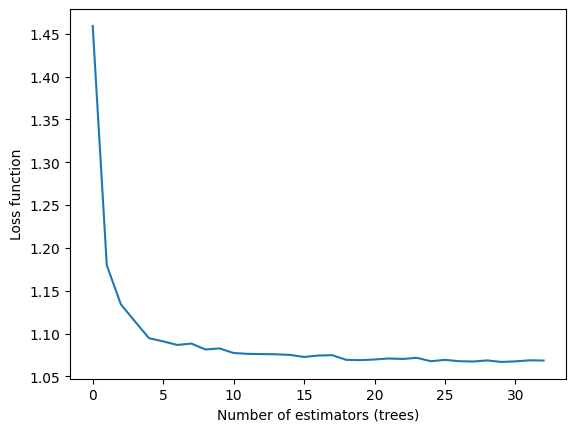

In [40]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**Answer**

I would **cut the plot with the number of estimators (trees)** and <u>keep</u> the one with **amount of training data**.

- **Explanation of my answer:**
    - The **training data plot** is more important because:
        - It shows how the model improves as we give it more data
        - This is a fundamental concept in machine learning (*learning curves*)
        - It tells us whether getting more data is useful

    - The **number of estimators plot** is less interesting because:
        - It usually just shows diminishing returns
        - After some point, adding more trees doesn’t improve much
        - It’s more of a tuning detail than a key insight

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [41]:
# Imported Packages
# --------------------

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load Preprocessed Dataset*

In [42]:
dataset_path = "data/dataset1_diabetes_preprocessed_week2.csv"
df_diabetes = pd.read_csv(dataset_path)

# drop index-like column
df_diabetes = df_diabetes.drop(columns=["Unnamed: 0"])

#### [Dataset 1] | *2- Prepare Data for Modelling*

In [43]:
X = df_diabetes.drop(columns=["Diabetes_012"])
y = df_diabetes["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

#### [Dataset 1] | *3- Before Tuning: Cross-Validation with Baseline Models (Random Forest / Logistic Regression / Gradient Boosting)*

In [44]:
# -----------------------------
# 2. Define baseline models
# -----------------------------
baseline_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0),

    # Logistic Regression with scaling
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
    ]),

    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=10, random_state=0)
}

# -----------------------------
# 3. Cross-validation (BEFORE tuning)
# -----------------------------
print("\nCross-validation results (baseline models):\n")

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Cross-validation results (baseline models):

Random Forest CV Accuracy: 0.8488
Logistic Regression CV Accuracy: 0.8466
Gradient Boosting CV Accuracy: 0.8469


#### [Dataset 1] | *4- Define Models + Parameter Spaces  (Random Forest / Logistic Regression / Gradient Boosting)*

In [45]:
models = {
    "Random Forest": (
        RandomForestClassifier(random_state=0),
        {
            "n_estimators": randint(50, 200),
            "max_depth": randint(5, 20),
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5)
        }
    ),

    # Logistic Regression: Pipeline + correct param naming
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
        ]),
        {
            "model__C": uniform(0.01, 10)
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=0),
        {
            "n_estimators": randint(20, 55),
            "learning_rate": uniform(0.01, 0.3),
            "max_depth": randint(3, 15)
        }
    )
}

#### [Dataset 1] | *5- Hyperparameter tuning: Run RandomizedSearchCV for each model*

In [46]:
best_models = {}

for name, (model, param_dist) in models.items():
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring="accuracy",
        random_state=0,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    best_models[name] = search.best_estimator_
    
    print(f"{name} best params:", search.best_params_)

Random Forest best params: {'max_depth': 17, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 117}
Logistic Regression best params: {'model__C': np.float64(5.498135039273247)}
Gradient Boosting best params: {'learning_rate': np.float64(0.1539931517125172), 'max_depth': 4, 'n_estimators': 45}


#### [Dataset 1] | *6- Evaluate all tuned models with multiple metrics*

In [47]:
results = []

for name, model in best_models.items():
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    sensitivity = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")
    
    # Specificity calculation (for multi-class, we need average)
    cm = confusion_matrix(y_test, preds)
    specificity_list = []
    
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity_list.append(tn / (tn + fp))
    
    specificity = sum(specificity_list) / len(specificity_list)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Sensitivity  Specificity  F1 Score
0        Random Forest  0.848707     0.379004     0.709268  0.386688
1  Logistic Regression  0.846243     0.385016     0.714523  0.394631
2    Gradient Boosting  0.850185     0.389922     0.719463  0.401636


#### [Dataset 1] | *7- Plot Comparison*

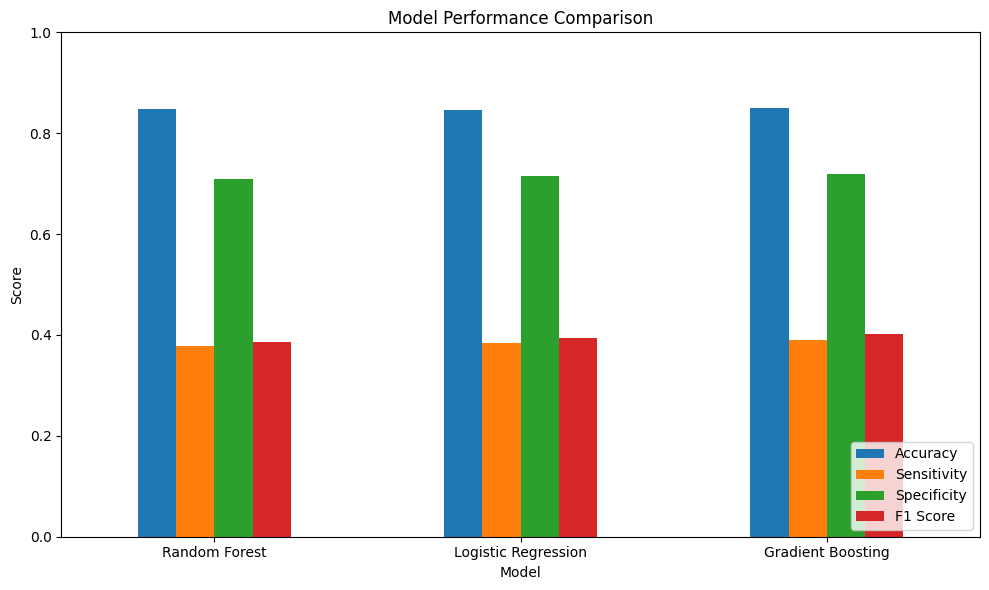

In [48]:

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### [Dataset 1] | *8- Interpretation*

**8.1.Baseline Performance**

The cross-validation results show that all three models perform very similarly, with accuracies around **84.7%–84.9%**:

- **Random Forest:** 0.8488  
- **Logistic Regression:** 0.8466  
- **Gradient Boosting:** 0.8469  

=> This indicates the dataset has a **clear signal**, but no model strongly dominates at baseline.  
=> **Random Forest slightly leads**, making it a strong candidate due to its ability to capture **nonlinear relationships**.

<br><br>


**8.2.Random Forest (Main Focus)**

After tuning, Random Forest selected:

- **n_estimators = 117**
- **max_depth = 17**
- **min_samples_leaf = 4**
- **min_samples_split = 7**

=> This reflects a **balanced model**:
- Complex enough to learn patterns  
- Regularized enough to avoid overfitting  

Test performance:

- **Accuracy:** 0.8487  

=> Very close to CV accuracy : **strong generalization**  
=> Random Forest is **stable and reliable**

<br><br>

**8.3.Accuracy vs Real Performance**

Despite strong accuracy, other metrics reveal limitations:

- **Sensitivity:** 0.379  
- **Specificity:** 0.709  
- **F1 Score:** 0.387  

Interpretation:
- Good at **overall classification**
- Weak at detecting **minority (diabetes) cases**

> **IMPORTANT**: In healthcare, **missing positive cases is costly**, so sensitivity matters more than accuracy alone.



**Model Comparison**

| Model                | Accuracy | Sensitivity | Specificity | F1 Score |
|---------------------|----------|------------|-------------|----------|
| Random Forest       | 0.8487   | 0.3790     | 0.7093      | 0.3867   |
| Logistic Regression | 0.8462   | 0.3850     | 0.7145      | 0.3946   |
| Gradient Boosting   | 0.8502   | 0.3899     | 0.7195      | 0.4016   |


=> **Gradient Boosting performs best overall**, especially in:
- Sensitivity  
- F1 score  

=> Random Forest remains:
- **Most stable**
- **Strong baseline performer**

<br><br>

**8.4.Root Cause: Class Imbalance**

The low sensitivity and F1 suggest:

- The dataset is **imbalanced**  
- There are **more non-diabetes cases than diabetes cases**

This causes models to:
- Favor the **majority class**
- Achieve high accuracy but miss minority cases  





#### [Dataset 1] | *9- Dealing with Class Imbalance*

**Techniques to Handle Class Imbalance**

To improve performance (especially for Random Forest), the following techniques can be applied:

- **1. Class Weighting (Cost-sensitive learning)**
    - RandomForestClassifier(class_weight="balanced")
    - Advantages:
        - By penalizing errors on minority samples more heavily, the model is encouraged to pay closer attention to them, improving recall without changing the dataset itself.

- **2. Oversampling (Increase Minority Class)**
    - Methods:
        - Random Oversampling
        - SMOTE (Synthetic Minority Oversampling Technique)
        - ADASYN

    - Advantages:
        - Oversampling increases the presence of minority class examples, allowing the model to better learn their patterns. 
        - SMOTE is particularly effective because it generates synthetic but realistic samples, reducing overfitting compared to simple duplication.

- **3. Undersampling (Reduce Majority Class)**

    - Methods:
        - Random Undersampling
        - Tomek Links
        - NearMiss

    - Advantages:
        - Reducing the number of majority class samples balances the dataset and forces the model to consider minority examples more carefully. 
        - However, it may discard useful information, so it should be used cautiously.

- **4. Hybrid Methods**

    - Examples:
        - SMOTE + Tomek Links
        - SMOTE + Edited Nearest Neighbors (ENN)

    - Advantages:
        - Combines the strengths of oversampling and undersampling by both adding informative minority samples and removing noisy or redundant majority samples, often leading to better overall performance.


- **5. Change Evaluation Metric**

    - Recommended metrics:
        - F1 Score
        - Recall (Sensitivity)
        - Balanced Accuracy
        - ROC-AUC

    - Advantages:
        - Accuracy alone can be misleading in imbalanced datasets. 
        - These metrics focus on how well the model identifies minority cases, ensuring performance reflects real-world needs.


- **6. Threshold Tuning**
    - Adjust the classification threshold (e.g., from 0.5 to 0.3).
    - Advantages:
        - Lowering the threshold increases the likelihood of predicting the minority class, improving sensitivity. 
        - This is particularly useful when missing positive cases is costly, such as in medical diagnosis.

- **7. Model-Specific Improvements (Random Forest)**

    - Examples:
        - class_weight="balanced_subsample"
        - Increase *min_samples_leaf*
        - Limit *tree depth*
        - Increase *number of trees*

    - Advantages:
        - These adjustments reduce the model’s bias toward the majority class and improve generalization, helping Random Forest better capture minority patterns.


- **8. Advanced Ensemble Methods**

    - Examples:
        - Balanced Random Forest
        - EasyEnsemble
        - XGBoost / LightGBM with class weighting

    - Advantages:
        - These methods are specifically designed for imbalanced data and combine resampling with ensemble learning to enhance minority class detection.

In [49]:
# ------------------------------------
# 1. Tuned Random Forest (baseline)
# ------------------------------------
rf_baseline = RandomForestClassifier(
    n_estimators=117,
    max_depth=17,
    min_samples_leaf=4,
    min_samples_split=7,
    random_state=0
)

# -------------------------------------------------
# 2. Tuned Random Forest with class weighting
# -------------------------------------------------
rf_weighted = RandomForestClassifier(
    n_estimators=117,
    max_depth=17,
    min_samples_leaf=4,
    min_samples_split=7,
    class_weight="balanced",  # The key change
    random_state=0
)

# -------------------------------------------
# 3. Cross-validation comparison
# -------------------------------------------

print("Cross-validation comparison:\n")

cv_base = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring="accuracy")
cv_weighted = cross_val_score(rf_weighted, X_train, y_train, cv=5, scoring="accuracy")

print(f"Baseline RF CV Accuracy: {cv_base.mean():.4f}")
print(f"Weighted RF CV Accuracy: {cv_weighted.mean():.4f}")

# ----------------------------------
# 4. Train both models
# ---------------------------------
rf_baseline.fit(X_train, y_train)
rf_weighted.fit(X_train, y_train)

# -----------------------------
# 5. Evaluation function
# -----------------------------

def evaluate_model(model, name):
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    sensitivity = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")
    
    cm = confusion_matrix(y_test, preds)
    specificity_list = []
    
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity_list.append(tn / (tn + fp))
    
    specificity = np.mean(specificity_list)
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    return acc, sensitivity, specificity, f1

# -----------------------------
# 6. Evaluate both models
# -----------------------------
base_results = evaluate_model(rf_baseline, "Baseline Random Forest")
weighted_results = evaluate_model(rf_weighted, "Weighted Random Forest")

Cross-validation comparison:

Baseline RF CV Accuracy: 0.8492
Weighted RF CV Accuracy: 0.7592

Baseline Random Forest
Accuracy: 0.8487
Sensitivity: 0.3790
Specificity: 0.7093
F1 Score: 0.3867

Weighted Random Forest
Accuracy: 0.7551
Sensitivity: 0.4998
Specificity: 0.8225
F1 Score: 0.4468


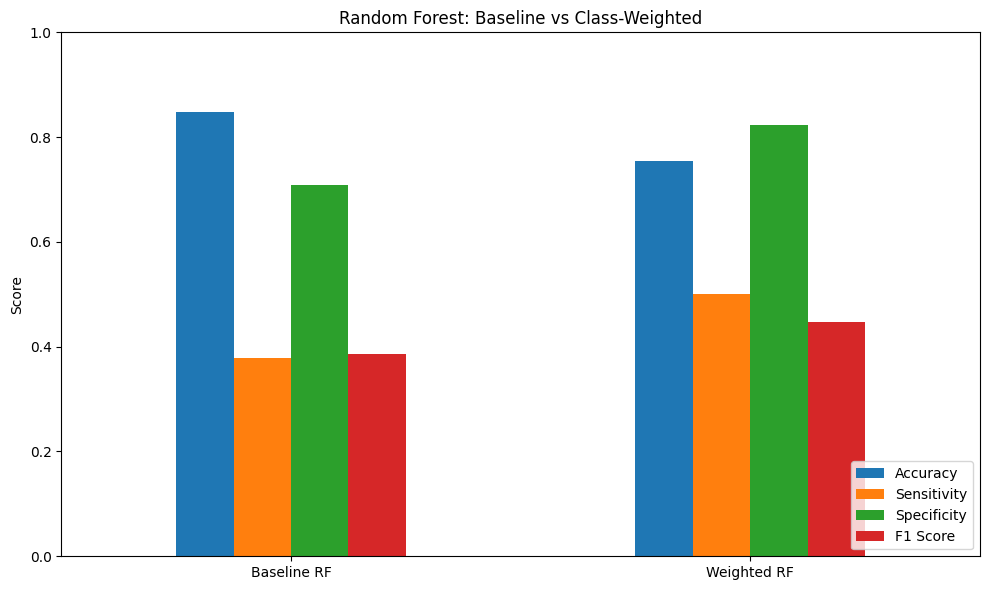

In [50]:
comparison_df = pd.DataFrame({
    "Baseline RF": base_results,
    "Weighted RF": weighted_results
}, index=["Accuracy", "Sensitivity", "Specificity", "F1 Score"])

comparison_df.T.plot(kind="bar", figsize=(10,6))

plt.title("Random Forest: Baseline vs Class-Weighted")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**<u>Effect of Class Weighting on Random Forest</u>**
<br>

**Results Summary**

| Model                  | Accuracy | Sensitivity | Specificity | F1 Score |
|-----------------------|----------|------------|-------------|----------|
| Baseline RF           | 0.8487   | 0.3790     | 0.7093      | 0.3867   |
| Weighted RF           | 0.7551   | 0.4998     | 0.8225      | 0.4468   |

<br>

**Key Takeaways**

- **Accuracy decreased** (0.85 → 0.76)  
    - Expected, since the model is less biased toward the majority class  

- **Sensitivity improved significantly** (0.38 → 0.50)  
    - Better detection of diabetes cases  

- **F1 score increased**  (0.39 → 0.45) 
    - More balanced overall performance  

- **Specificity also improved**  (0.71 → 0.82) 
    - Better classification of non-diabetes cases  

<br>

**Interpretation**

- Class weighting forces the model to pay more attention to minority cases, leading to **better balanced predictions**. 
- Although accuracy drops, the improvements in sensitivity and F1 make the model more useful for this medical problem.

<br>

**Final Insight**

> In healthcare, **detecting positive cases matters more than maximizing accuracy**

> The **Weighted Random Forest is more appropriate** despite lower accuracy.

#### [Dataset 1] | *10- Feature Importance (using Random Forest)*

      Feature  Importance
3         BMI    0.171176
13    GenHlth    0.142576
0      HighBP    0.107768
18        Age    0.097845
15   PhysHlth    0.063524
20     Income    0.062738
1    HighChol    0.061979
16   DiffWalk    0.049750
14   MentHlth    0.044808
19  Education    0.039983


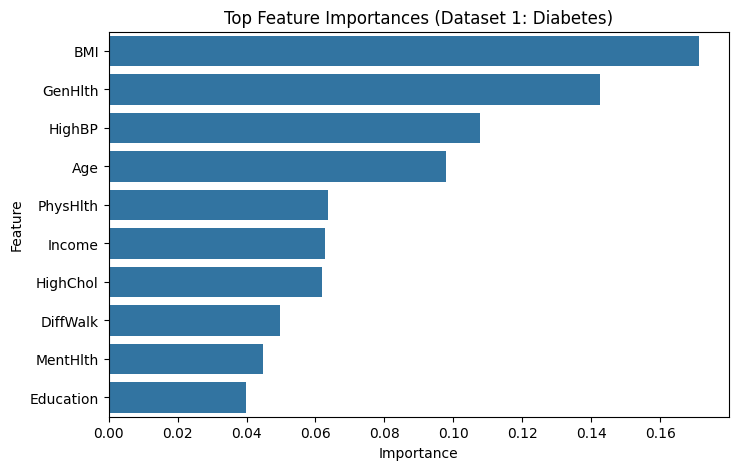

In [52]:

import seaborn as sns

target_col = "Diabetes_012"

X = df_diabetes.drop(columns=[target_col])
y = df_diabetes[target_col]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# -----------------------------
# Random Forest + Feature Importance
# -----------------------------
rf = RandomForestClassifier(max_depth= 17, min_samples_leaf= 4, min_samples_split= 7, n_estimators= 117, random_state=0, n_jobs=-1) # with fine-tuned hyperparams
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances (Dataset 1: Diabetes)")
plt.show()

**Interpretation of Feature Importance (Dataset 1: Diabetes)**

**Key Drivers of Prediction**
- **BMI** is the most important feature by a clear margin  
- Followed by:
  - **General Health (GenHlth)**
  - **High Blood Pressure (HighBP)**
  - **Age**

=> These are all **strong medical risk indicators**, which makes intuitive sense

<br>

**Secondary Factors**
- Features like:
  - **Physical Health (PhysHlth)**
  - **Income**
  - **High Cholesterol (HighChol)**
  - **Difficulty Walking (DiffWalk)**  
  also contribute meaningfully

=> These reflect **lifestyle and socioeconomic conditions**

<br>

**Important Insight**

> The model relies heavily on **health status + chronic condition indicators**

=> This suggests:
- Diabetes is strongly linked to **overall physical condition**
- Not just one factor, but a **combination of health risks**

<br>

**Final Takeaway**

- **BMI is the dominant predictor**
- Followed by a mix of:
  - Medical conditions  
  - Lifestyle indicators  
- The model captures a **multifactorial view of diabetes risk**

> Diabetes prediction is driven by **both biological and lifestyle factors**

## Dataset 2: Estimation of Obesity Levels Based on Eating Habits and Physical Condition

#### [Dataset 2] | *1- Load Preprocessed Dataset*

In [53]:
df_obesity = pd.read_csv("data/dataset2_obesity_preprocessed_week2_1.csv")

df_obesity = df_obesity.drop(columns=["Unnamed: 0"])

#### [Dataset 2] | *2- Prepare Data for Modelling*

In [54]:
# -----------------------------
# 2. map target variable
# -----------------------------
def map_obesity(x):
    if x in ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II"]:
        return 0  # Not obese
    elif x == "Obesity_Type_I":
        return 1
    elif x == "Obesity_Type_II":
        return 2
    else:
        return 3  # Obesity_Type_III

df_obesity["Obesity_Level"] = df_obesity["NObeyesdad"].apply(map_obesity)

X = df_obesity.drop(columns=["NObeyesdad", "Obesity_Level"])
y = df_obesity["Obesity_Level"]

# -----------------------------
# 3. Identify column types
# -----------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# -----------------------------
# 4. Preprocessors
# -----------------------------
tree_preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

linear_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

C:\Users\jdhao\AppData\Local\Temp\ipykernel_17044\235033264.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


#### [Dataset 2] | *3- Before Tuning: Cross-Validation with Baseline Models (Random Forest / Logistic Regression / Gradient Boosting)*

In [55]:
# -----------------------------
# 5. Baseline models
# -----------------------------
baseline_models = {
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=12, random_state=0))
    ]),

    "Logistic Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=0))
    ])
}

# -----------------------------
# 6. Cross-validation
# -----------------------------
print("\nCross-validation results:\n")

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Cross-validation results:

Random Forest CV Accuracy: 0.9976
Logistic Regression CV Accuracy: 0.9882
Gradient Boosting CV Accuracy: 0.9929


#### [Dataset 2] | *4- Define Models + Parameter Spaces  (Random Forest / Logistic Regression / Gradient Boosting)*

In [56]:
# -----------------------------
# 7. Models + tuning spaces
# -----------------------------
models = {
    "Random Forest": (
        Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(random_state=0))
        ]),
        {
            "model__n_estimators": randint(50, 200),
            "model__max_depth": randint(5, 20),
            "model__min_samples_split": randint(2, 10),
            "model__min_samples_leaf": randint(1, 5)
        }
    ),

    "Logistic Regression": (
        Pipeline([
            ("preprocessor", linear_preprocessor),
            ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
        ]),
        {
            "model__C": uniform(0.01, 10)
        }
    ),

    "Gradient Boosting": (
        Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", GradientBoostingClassifier(random_state=0))
        ]),
        {
            "model__n_estimators": randint(20, 55),
            "model__learning_rate": uniform(0.01, 0.3),
            "model__max_depth": randint(3, 10)
        }
    )
}

#### [Dataset 2] | *5- Hyperparameter tuning: Run RandomizedSearchCV for each model*

In [57]:
# -----------------------------
# 8. Hyperparameter tuning
# -----------------------------
best_models = {}

for name, (model, param_dist) in models.items():
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring="accuracy",
        random_state=0,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    print(f"{name} best params:", search.best_params_)

Random Forest best params: {'model__max_depth': 14, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 129}
Logistic Regression best params: {'model__C': np.float64(7.161893663724195)}
Gradient Boosting best params: {'model__learning_rate': np.float64(0.17464405117819742), 'model__max_depth': 8, 'model__n_estimators': 20}


#### [Dataset 2] | *6- Evaluate all tuned models with multiple metrics*

In [58]:
# -----------------------------
# 9. Evaluation
# -----------------------------
results = []

for name, model in best_models.items():
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    sensitivity = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")

    # Specificity (multi-class)
    cm = confusion_matrix(y_test, preds)
    specificity_list = []

    for i in range(len(cm)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity_list.append(tn / (tn + fp))

    specificity = np.mean(specificity_list)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("\nFinal Model Performance:\n")
print(results_df)


Final Model Performance:

                 Model  Accuracy  Sensitivity  Specificity  F1 Score
0        Random Forest  0.995272     0.991987     0.998603  0.992122
1  Logistic Regression  0.988180     0.981868     0.995963  0.982098
2    Gradient Boosting  0.990544     0.987640     0.996632  0.987327


#### [Dataset 2] | *7- Plot Comparison*

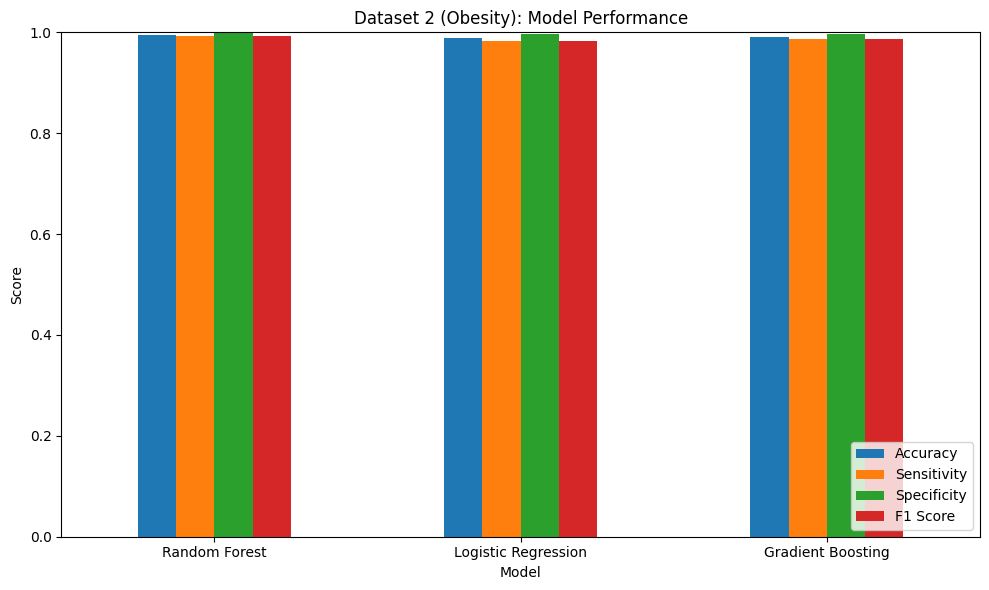

In [59]:
# -----------------------------
# 10. Plot comparison
# -----------------------------
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Dataset 2 (Obesity): Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### [Dataset 2] | *8- Interpretation*


**8.1 Overall Performance**

All models perform **extremely well**:

- Random Forest: ~99.5% (accuracy) 
- Gradient Boosting: ~99.1%   (accuracy) 
- Logistic Regression: ~98.8%   (accuracy) 

=> Metrics like **sensitivity, specificity, and F1** are also all above **98%**, which means the models are predicting all classes very accurately.

<br>

**8.2 Random Forest (Main Focus)**

Random Forest is the **best model**:

- Accuracy: **0.995**
- Sensitivity: **0.992**
- F1 Score: **0.992**

=> It performs slightly better than the others, but the gap is small.

<br>

**8.3 Important Insight**

These results are **almost too perfect**.

- This is likely because **BMI is included**, and:
    - Obesity classes are directly related to BMI  
    - The model can easily learn **BMI → obesity level**

=> So the model is using a **shortcut**, not learning deeper patterns.

<br>

**8.4 Final Takeaway**

- All models perform very well, but the problem is **too easy**
- Random Forest is the best, but not by much  
- Results are likely **inflated due to BMI (possible data leakage)**  


#### [Dataset 2] | *9- Feature Importance (using Random Forest)*

                               Feature  Importance
8                                  BMI    0.363718
2                               Weight    0.253045
3                                 FCVC    0.082009
0                                  Age    0.056587
9                          Gender_Male    0.043145
1                               Height    0.042028
4                                  NCP    0.021885
10  family_history_with_overweight_yes    0.020655
7                                  TUE    0.020621
5                                 CH2O    0.018745


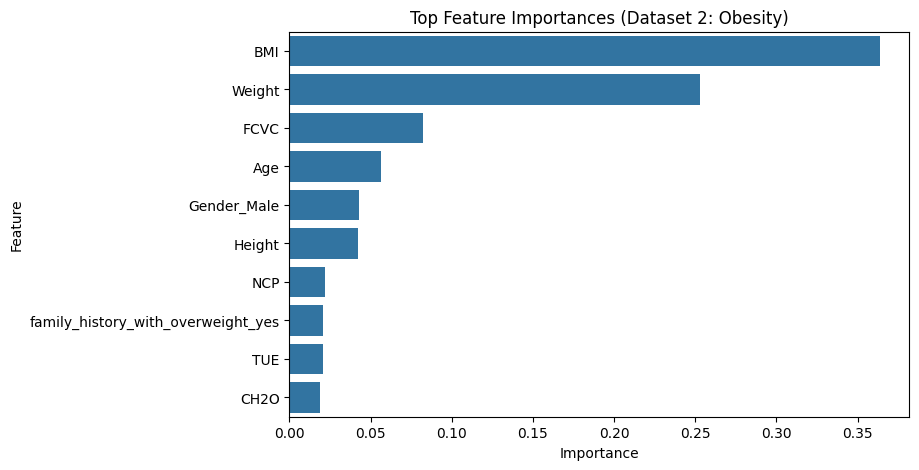

In [62]:
X = df_obesity.drop(columns=["NObeyesdad", "Obesity_Level"])
y = df_obesity["Obesity_Level"]

# -----------------------------
# One-hot encoding
# -----------------------------
X_encoded = pd.get_dummies(X, drop_first=True)

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=0, stratify=y
)

# -----------------------------
# Random Forest + Feature Importance
# -----------------------------
params = {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 129, "random_state":0, "n_jobs":-1}
rf = RandomForestClassifier(**params)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances (Dataset 2: Obesity)")
plt.show()

**Interpretation of Feature Importance (Dataset 2: Obesity)**

- **BMI and Weight dominate** by a large margin  
- All other features contribute **very little in comparison**

=> This shows:

> Obesity classification is driven almost entirely by **body composition features**

<br>

**Takeaway**

- The model relies heavily on **direct indicators of obesity (BMI, Weight)**  
- Other lifestyle or behavioral features play a **minor role**

> This explains the **very high model accuracy** and strong separability

## Dataset 3: Cervical Cancer (Risk Factors)

#### [Dataset 3] | *1- Load Preprocessed Dataset*

In [63]:
df_cervical_clean = pd.read_csv("data/dataset3_cervical_clean_preprocessed_week2.csv")

# cleanups
df_cervical_clean = df_cervical_clean.drop(columns=[col for col in df_cervical_clean.columns if "Unnamed" in col])

#### [Dataset 3] | *2- Prepare Data for Modelling*

In [64]:
# -----------------------------
# 2. Define target
# -----------------------------
target_col = "Biopsy"

X = df_cervical_clean.drop(columns=[target_col])
y = df_cervical_clean[target_col]

# -----------------------------
# 3. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

#### [Dataset 3] | *3- Before Tuning: Cross-Validation with Baseline Models (Random Forest / Logistic Regression / Gradient Boosting)*

In [65]:
# -----------------------------
# 4. Preprocessing
# -----------------------------
# Tree models don't need scaling
# Logistic regression does

rf_pipe = Pipeline([
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0))
])

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
])

gb_pipe = Pipeline([
    ("model", GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=0))
])

baseline_models = {
    "Random Forest": rf_pipe,
    "Logistic Regression": lr_pipe,
    "Gradient Boosting": gb_pipe
}

# -----------------------------
# 5. Cross-validation
# -----------------------------
print("\nCross-validation results:\n")

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Cross-validation results:

Random Forest CV Accuracy: 0.9461
Logistic Regression CV Accuracy: 0.9491
Gradient Boosting CV Accuracy: 0.9461


#### [Dataset 3] | *4- Define Models + Parameter Spaces  (Random Forest / Logistic Regression / Gradient Boosting)*

In [66]:
# -----------------------------
# 6. Models + tuning spaces
# -----------------------------
models = {
    "Random Forest": (
        Pipeline([
            ("model", RandomForestClassifier(random_state=0))
        ]),
        {
            "model__n_estimators": randint(50, 200),
            "model__max_depth": randint(5, 20),
            "model__min_samples_split": randint(2, 10),
            "model__min_samples_leaf": randint(1, 5)
        }
    ),

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
        ]),
        {
            "model__C": uniform(0.01, 10)
        }
    ),

    "Gradient Boosting": (
        Pipeline([
            ("model", GradientBoostingClassifier(random_state=0))
        ]),
        {
            "model__n_estimators": randint(20, 55),
            "model__learning_rate": uniform(0.01, 0.3),
            "model__max_depth": randint(3, 10)
        }
    )
}

#### [Dataset 3] | *5- Hyperparameter tuning: Run RandomizedSearchCV for each model*

In [67]:
# -----------------------------
# 7. Hyperparameter tuning
# -----------------------------
best_models = {}

for name, (model, param_dist) in models.items():
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring="accuracy",
        random_state=0,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    print(f"{name} best params:", search.best_params_)

Random Forest best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 122}
Logistic Regression best params: {'model__C': np.float64(5.498135039273247)}
Gradient Boosting best params: {'model__learning_rate': np.float64(0.031310817459366085), 'model__max_depth': 4, 'model__n_estimators': 40}


#### [Dataset 3] | *6- Evaluate all tuned models with multiple metrics*

In [68]:
# -----------------------------
# 8. Evaluation
# -----------------------------
results = []

for name, model in best_models.items():
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    sensitivity = recall_score(y_test, preds)  # binary
    f1 = f1_score(y_test, preds)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("\nFinal Model Performance:\n")
print(results_df)


Final Model Performance:

                 Model  Accuracy  Sensitivity  Specificity  F1 Score
0        Random Forest  0.970060     0.636364     0.993590  0.736842
1  Logistic Regression  0.952096     0.545455     0.980769  0.600000
2    Gradient Boosting  0.958084     0.545455     0.987179  0.631579


#### [Dataset 3] | *7- Plot Comparison*

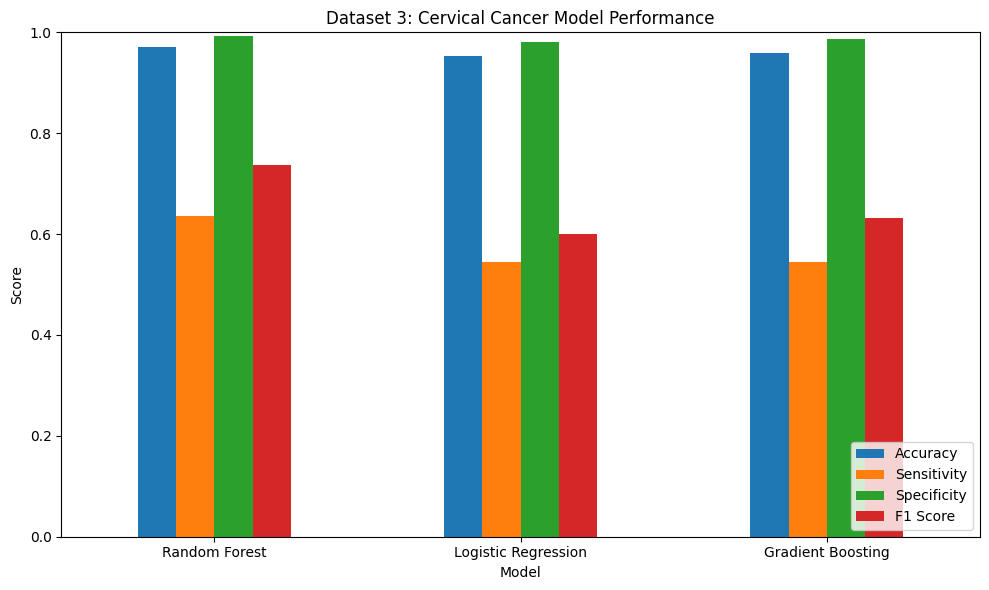

In [69]:
# -----------------------------
# 9. Plot comparison
# -----------------------------
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Dataset 3: Cervical Cancer Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### [Dataset 3] | *8- Interpretation*


**8.1 Overall Performance**

All models perform well in cross-validation (~94–95% accuracy), with very small differences between them. This indicates the dataset has **learnable patterns**, but no model strongly dominates at baseline.

<br>

**8.2 Random Forest (Best Model)**

Random Forest achieves the **best test performance**:

- **Accuracy:** 0.970  
- **Sensitivity:** 0.636  
- **F1 Score:** 0.737  

=> It performs better than the other models, especially in **detecting cancer cases**.

<br>

**8.3 Key Insight: Class Imbalance**

Despite high accuracy, **sensitivity is relatively low** (~0.55–0.64):

=> Models are very good at predicting **non-cancer cases** (high specificity ~0.98–0.99)  
=> But less effective at detecting **cancer cases**

> This suggests the dataset is **imbalanced**
> Techniques dealing with Class Imbalance are stated while working with Dataset 1 (Diabetes) [look at the relative sections above]

<br>

**8.4 Final Takeaway**

- **Random Forest is the best model overall**
- However, performance is driven mainly by the majority class  
- Detecting cancer cases is still challenging  

> Next step: apply **class imbalance techniques** to improve sensitivity  

> In medical problems, **recall (sensitivity) matters more than accuracy**

#### [Dataset 3] | *9- Feature Importance (using Random Forest)*

                            Feature  Importance
31                         Schiller    0.391200
30                       Hinselmann    0.170010
32                         Citology    0.093758
0                               Age    0.062767
8   Hormonal Contraceptives (years)    0.052581
2          First sexual intercourse    0.045010
1         Number of sexual partners    0.028412
3                Num of pregnancies    0.026615
6               Smokes (packs/year)    0.012768
5                    Smokes (years)    0.012168


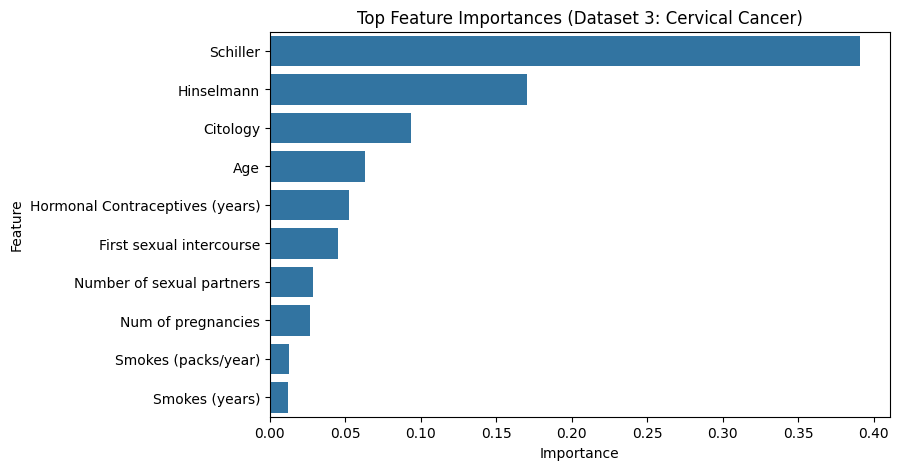

In [70]:
target_col = "Biopsy"

X = df_cervical_clean.drop(columns=[target_col])
y = df_cervical_clean[target_col]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# -----------------------------
# Random Forest + Feature Importance
# -----------------------------
params = {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 122, "random_state":0, "n_jobs":-1}
rf = RandomForestClassifier(**params)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances (Dataset 3: Cervical Cancer)")
plt.show()

**Interpretation of Feature Importance (Dataset 3: Cervical Cancer)**

- **Screening test results (Schiller, Hinselmann, Cytology)** dominate the model  
- Other features (age, sexual behavior, smoking) have **much smaller impact**

=> This shows:

> The model relies mainly on **medical test outcomes**, not underlying risk factors

<br>

**Takeaway**
- Predictions are driven by **diagnostic signals rather than lifestyle variables**  
- This explains why classification works, but **early risk prediction remains challenging**

> The model is better at **detecting existing conditions** than predicting risk

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

### Answer:
[**Note** : I used dummy data to reproduce the graph]
</br> </br>
The given page range **does not** include any graph to reproduce. For that reason, I am considering again the page range given in the previous <u>homework (HW10/week10): "Reproduce any graph of your choice in chapter six (p. 151-163)"</u> 
</br> </br>
The graph selected for reproduction is **Figure 6.3 from page 156 of the book (Introduction of Storytelling With Data)**.

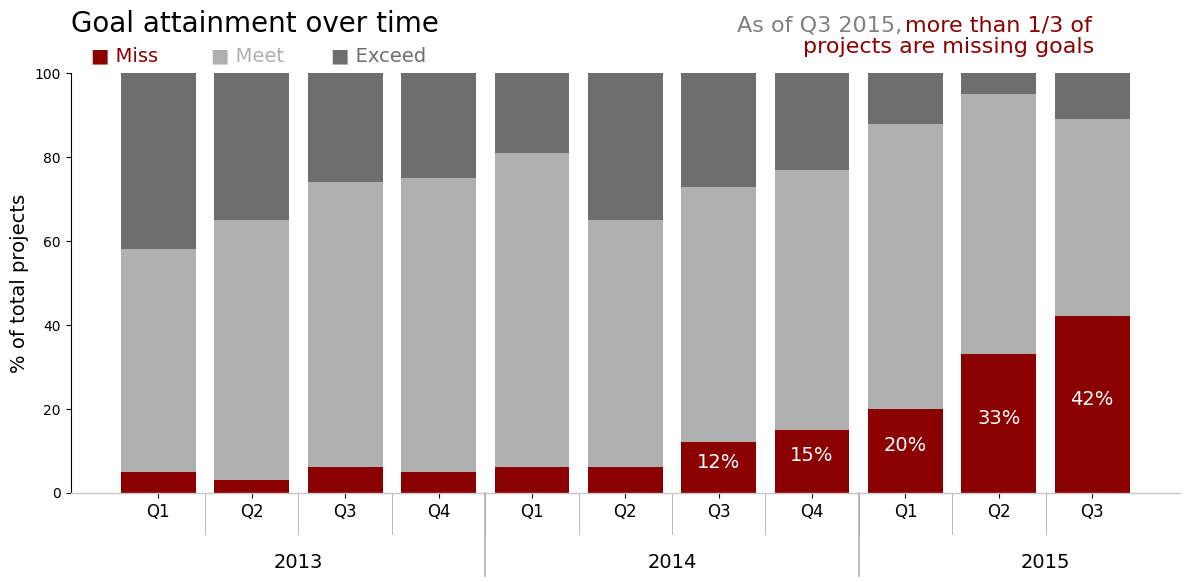

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ["Q1","Q2","Q3","Q4","Q1","Q2","Q3","Q4","Q1","Q2","Q3"]
miss = np.array([5,3,6,5,6,6,12,15,20,33,42])
meet = np.array([53,62,68,70,75,59,61,62,68,62,47])
exceed = 100 - miss - meet

x = np.arange(len(labels))

colors = {
    "miss": "#8B0000",
    "meet": "#B0B0B0",
    "exceed": "#6E6E6E"
}

fig, ax = plt.subplots(figsize=(12,6))

# --- Bars ---
ax.bar(x, miss, color=colors["miss"])
ax.bar(x, meet, bottom=miss, color=colors["meet"])
ax.bar(x, exceed, bottom=miss+meet, color=colors["exceed"])

# --- Axes ---
ax.set_ylim(0, 100)
ax.set_ylabel("% of total projects", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

# --- Title ---
ax.set_title("Goal attainment over time", fontsize=20, loc='left', pad=30)

# --- Legend-style labels ---
fig.text(0.08, 0.89, "■ Miss", color=colors["miss"], fontsize=14)
fig.text(0.18, 0.89, "■ Meet", color=colors["meet"], fontsize=14)
fig.text(0.28, 0.89, "■ Exceed", color=colors["exceed"], fontsize=14)

# --- Quarter separators (short) ---
for sep in np.arange(0.5, len(x)-0.5, 1):
    ax.plot([sep, sep], [0, -10],
            color="#B0B0B0",
            linewidth=0.6,
            clip_on=False)

# --- Year separators (longer) ---
for sep in [3.5, 7.5]:
    ax.plot([sep, sep], [0, -20],
            color="#B0B0B0",
            linewidth=1.2,
            clip_on=False)

# --- Year labels ---
ax.text(1.5, -18, "2013", ha='center', fontsize=14)
ax.text(5.5, -18, "2014", ha='center', fontsize=14)
ax.text(9.5, -18, "2015", ha='center', fontsize=14)

# --- Annotation ---
ax.text(6.2, 110, "As of Q3 2015,", fontsize=16, color="gray")
ax.text(8.0, 110,
        "more than 1/3 of",
        fontsize=16, color="#8B0000")
ax.text(6.9, 105,
        "projects are missing goals",
        fontsize=16, color="#8B0000")

# --- Labels inside bars ---
for i in range(6, 11):
    ax.text(i, miss[i]/2, f"{miss[i]}%",
            ha='center', color="white", fontsize=14)

# --- Style cleanup ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("#C7C7C7")
ax.spines['bottom'].set_linewidth(1)

plt.tight_layout()
plt.show()